In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("../dataset/original_dataset/ecommerce_orders_dataset.csv")

In [4]:
data_dict = pd.read_csv("../dataset/original_dataset/data_dictionary.csv")

In [5]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [6]:
data_dict.head()

,Column,Description
0,Order_ID,Unique order identifier
1,Customer_ID,Unique customer identifier
2,Order_Date,Date when the order was placed
3,Year,Order year
4,Month,Order month


### 1. Data Understanding

In [8]:
df.shape

(30000, 41)

In [9]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  str    
 2   Order_Date               30000 non-null  str    
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  str    
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  str    
 10  Country                  30000 non-null  str    
 11  City                     30000 non-null  str    
 12  Customer_Segment         30000 non-null  str    
 13  Product_ID               30000 non-null  str    
 14  Product_Category         30000 no

In [11]:
df.describe()

,Order_ID,Year,Month,Day,Quarter,Customer_Age,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Shipping_Cost,Tax_Amount,Order_Amount,Delivery_Days,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,615000.500000,2024.494700,6.531500,15.723600,2.507000,36.370300,126.820148,3.080667,12.618667,49.432742,10.316779,29.143818,379.001466,4.436667,4.047990,4372.340178,21.969056,73.863876
std,8660.398374,1.118815,3.460955,8.779714,1.118806,11.315534,172.675272,1.450412,11.085201,114.401634,5.890701,49.562251,585.405554,2.349363,0.686492,6811.029394,9.079134,113.480736
min,600001.000000,2023.000000,1.000000,1.000000,1.000000,18.000000,3.840000,1.000000,0.000000,0.000000,0.000000,0.260000,6.670000,0.000000,1.000000,20.000000,3.000000,0.270000
25%,607500.750000,2023.000000,4.000000,8.000000,2.000000,28.000000,29.880000,2.000000,0.000000,0.000000,6.020000,5.270000,82.947500,3.000000,3.600000,1029.637500,15.680000,16.640000
50%,615000.500000,2024.000000,7.000000,16.000000,3.000000,36.000000,60.670000,3.000000,10.000000,13.470000,9.000000,12.065000,171.030000,4.000000,4.100000,2073.365000,21.870000,36.995000
75%,622500.250000,2025.000000,10.000000,23.000000,4.000000,44.000000,128.572500,4.000000,20.000000,44.822500,14.220000,29.442500,388.190000,6.000000,4.600000,4482.105000,28.180000,82.125000
max,630000.000000,2026.000000,12.000000,31.000000,4.000000,75.000000,1940.000000,11.000000,40.000000,2623.900000,32.600000,1043.160000,10314.270000,13.000000,5.000000,50000.000000,56.610000,2480.540000


In [13]:
df.describe(include="all")

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
count,30000.000000,30000,30000,30000.000000,30000.000000,30000.000000,30000,30000.000000,30000.000000,30000,30000,30000,30000,30000,30000,30000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000.000000,30000.000000,30000.000000,30000,30000,30000,30000,30000,30000,30000.000000,30000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000,30000
unique,NaN,8683,1461,NaN,NaN,NaN,7,NaN,NaN,3,10,10,4,2500,8,32,10,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,6,3,6,4,4,5,NaN,5,2,NaN,NaN,NaN,NaN,4,2,2
top,NaN,CUST000031,2024-03-09,NaN,NaN,NaN,Monday,NaN,NaN,Female,Canada,London,Returning,PROD02344,Fashion,Men Clothing,Zenith,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Credit Card,Mobile,Organic Search,Standard,Standard,West,NaN,Delivered,No,NaN,NaN,NaN,NaN,Summer,No,No
freq,NaN,14,39,NaN,NaN,NaN,4327,NaN,NaN,14863,3099,3089,11987,27,6092,1591,3099,NaN,NaN,NaN,NaN,20429,NaN,NaN,NaN,5080,18538,5098,16049,16420,6060,NaN,19497,26967,NaN,NaN,NaN,NaN,7575,25550,22499
mean,615000.500000,NaN,NaN,2024.494700,6.531500,15.723600,NaN,2.507000,36.370300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.820148,3.080667,12.618667,49.432742,NaN,10.316779,29.143818,379.001466,NaN,NaN,NaN,NaN,NaN,NaN,4.436667,NaN,NaN,4.047990,4372.340178,21.969056,73.863876,NaN,NaN,NaN
std,8660.398374,NaN,NaN,1.118815,3.460955,8.779714,NaN,1.118806,11.315534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.675272,1.450412,11.085201,114.401634,NaN,5.890701,49.562251,585.405554,NaN,NaN,NaN,NaN,NaN,NaN,2.349363,NaN,NaN,0.686492,6811.029394,9.079134,113.480736,NaN,NaN,NaN
min,600001.000000,NaN,NaN,2023.000000,1.000000,1.000000,NaN,1.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.840000,1.000000,0.000000,0.000000,NaN,0.000000,0.260000,6.670000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.000000,20.000000,3.000000,0.270000,NaN,NaN,NaN
25%,607500.750000,NaN,NaN,2023.000000,4.000000,8.000000,NaN,2.000000,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.880000,2.000000,0.000000,0.000000,NaN,6.020000,5.270000,82.947500,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,3.600000,1029.637500,15.680000,16.640000,NaN,NaN,NaN
50%,615000.500000,NaN,NaN,2024.000000,7.000000,16.000000,NaN,3.000000,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.670000,3.000000,10.000000,13.470000,NaN,9.000000,12.065000,171.030000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,4.100000,2073.365000,21.870000,36.995000,NaN,NaN,NaN
75%,622500.250000,NaN,NaN,2025.000000,10.000000,23.000000,NaN,4.000000,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.572500,4.000000,20.000000,44.822500,NaN,14.220000,29.442500,388.190000,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,4.600000,4482.105000,28.180000,82.125000,NaN,NaN,NaN


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,30000.0,NaN,NaN,NaN,615000.5,8660.398374,600001.0,607500.75,615000.5,622500.25,630000.0
Customer_ID,30000,8683,CUST000031,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,30000,1461,2024-03-09,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,30000.0,NaN,NaN,NaN,2024.4947,1.118815,2023.0,2023.0,2024.0,2025.0,2026.0
Month,30000.0,NaN,NaN,NaN,6.5315,3.460955,1.0,4.0,7.0,10.0,12.0
Day,30000.0,NaN,NaN,NaN,15.7236,8.779714,1.0,8.0,16.0,23.0,31.0
Day_Of_Week,30000,7,Monday,4327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quarter,30000.0,NaN,NaN,NaN,2.507,1.118806,1.0,2.0,3.0,4.0,4.0
Customer_Age,30000.0,NaN,NaN,NaN,36.3703,11.315534,18.0,28.0,36.0,44.0,75.0
Customer_Gender,30000,3,Female,14863,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Observations
- Dataset contains 30,000 rows and 41 columns.
- No missing values are present.
- Dataset contains both numerical and categorical features.

In [15]:
df.isnull().sum()

Order_ID                   0
Customer_ID                0
Order_Date                 0
Year                       0
Month                      0
Day                        0
Day_Of_Week                0
Quarter                    0
Customer_Age               0
Customer_Gender            0
Country                    0
City                       0
Customer_Segment           0
Product_ID                 0
Product_Category           0
Product_Subcategory        0
Brand                      0
Unit_Price                 0
Quantity                   0
Discount_Percent           0
Discount_Amount            0
Coupon_Used                0
Shipping_Cost              0
Tax_Amount                 0
Order_Amount               0
Payment_Method             0
Device_Type                0
Traffic_Source             0
Membership_Status          0
Shipping_Method            0
Warehouse_Region           0
Delivery_Days              0
Order_Status               0
Returned                   0
Review_Rating 

In [16]:
df.duplicated().sum()

np.int64(0)

### 2. Unique Values

In [17]:
df.nunique()

Order_ID                   30000
Customer_ID                 8683
Order_Date                  1461
Year                           4
Month                         12
Day                           31
Day_Of_Week                    7
Quarter                        4
Customer_Age                  58
Customer_Gender                3
Country                       10
City                          10
Customer_Segment               4
Product_ID                  2500
Product_Category               8
Product_Subcategory           32
Brand                         10
Unit_Price                 16271
Quantity                      11
Discount_Percent               9
Discount_Amount            10098
Coupon_Used                    2
Shipping_Cost               2731
Tax_Amount                  8125
Order_Amount               22962
Payment_Method                 6
Device_Type                    3
Traffic_Source                 6
Membership_Status              4
Shipping_Method                4
Warehouse_

In [18]:
df.nunique().sort_values()

Coupon_Used                    2
High_Value_Order               2
Holiday_Season                 2
Returned                       2
Device_Type                    3
Customer_Gender                3
Shipping_Method                4
Year                           4
Season                         4
Membership_Status              4
Customer_Segment               4
Quarter                        4
Warehouse_Region               5
Order_Status                   5
Traffic_Source                 6
Payment_Method                 6
Day_Of_Week                    7
Product_Category               8
Discount_Percent               9
Country                       10
Brand                         10
City                          10
Quantity                      11
Month                         12
Delivery_Days                 14
Day                           31
Product_Subcategory           32
Review_Rating                 41
Customer_Age                  58
Order_Date                  1461
Product_ID

### 3. Target Variable Distribution

In [19]:
df["High_Value_Order"].value_counts()

High_Value_Order
No     22499
Yes     7501
Name: count, dtype: int64

In [20]:
df["High_Value_Order"].value_counts(normalize=True) * 100

High_Value_Order
No     74.996667
Yes    25.003333
Name: proportion, dtype: float64

##### Observations
- 22,499 (75%) orders are not high-value.
- 7,501 (25%) orders are high-value.
- The target variable is moderately imbalanced.

##### Target Variable Visualization

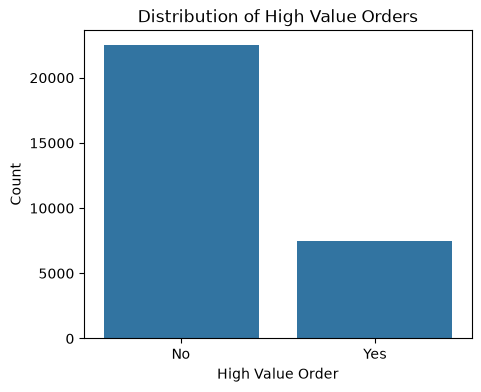

In [21]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="High_Value_Order")
plt.title("Distribution of High Value Orders")
plt.xlabel("High Value Order")
plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

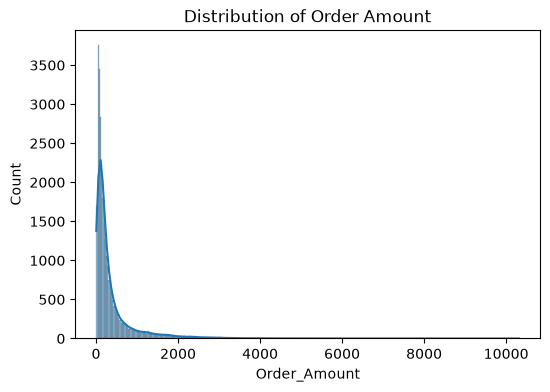

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["Order_Amount"], kde=True)
plt.title("Distribution of Order Amount")
plt.show

In [23]:
df["Order_Amount"].describe()

count    30000.000000
mean       379.001466
std        585.405554
min          6.670000
25%         82.947500
50%        171.030000
75%        388.190000
max      10314.270000
Name: Order_Amount, dtype: float64

##### Observations

- The distribution of Order Amount is highly right-skewed.
- The mean (379.00) is much higher than the median (171.03), indicating the presence of high-value orders.
- The maximum order amount (10314.27) is significantly higher than the third quartile (388.19), suggesting potential outliers.

# 2. Exploratory Data Analysis (EDA)

## 2.1 Univariate Analysis

#### 1. Order_Amount

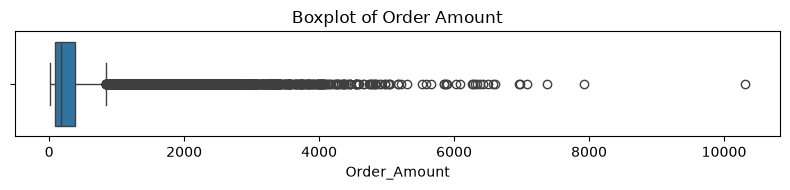

In [25]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Order_Amount"])
plt.title("Boxplot of Order Amount")
plt.tight_layout()
plt.show()

#### 2. Unit_Price

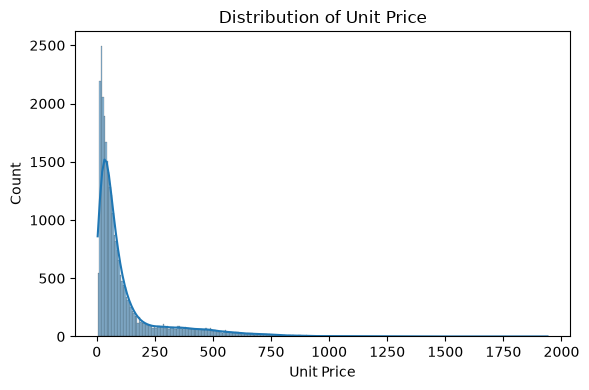

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df["Unit_Price"], kde=True)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

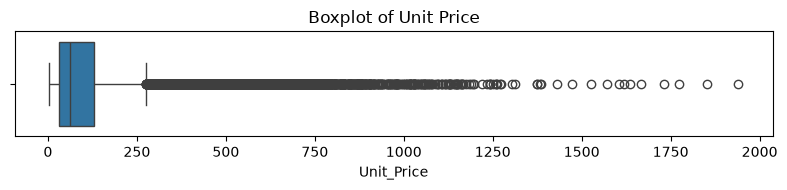

In [28]:
df["Unit_Price"].describe()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Unit_Price"])
plt.title("Boxplot of Unit Price")
plt.tight_layout()
plt.show()

#### 3. Customer_Age

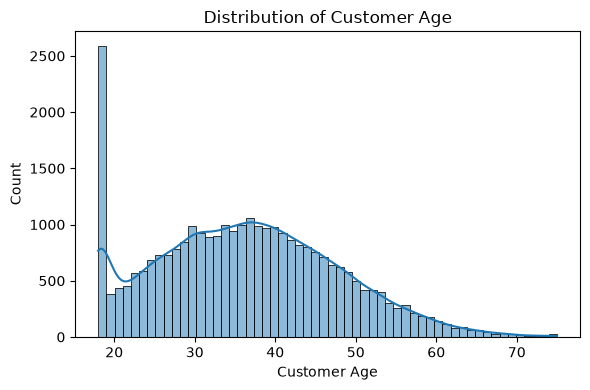

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df["Customer_Age"], kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [30]:
df["Customer_Age"].describe()

count    30000.000000
mean        36.370300
std         11.315534
min         18.000000
25%         28.000000
50%         36.000000
75%         44.000000
max         75.000000
Name: Customer_Age, dtype: float64

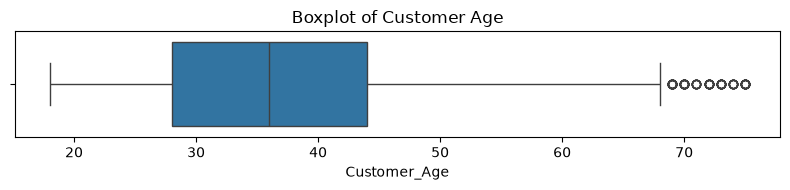

In [31]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Customer_Age"])
plt.title("Boxplot of Customer Age")
plt.tight_layout()
plt.show()

#### 4. Quantity

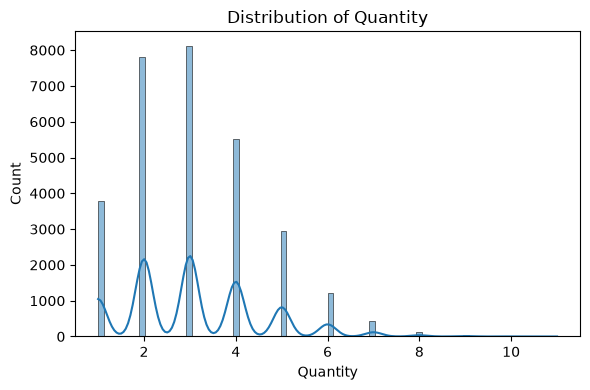

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df["Quantity"], kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [33]:
df["Quantity"].describe()

count    30000.000000
mean         3.080667
std          1.450412
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         11.000000
Name: Quantity, dtype: float64

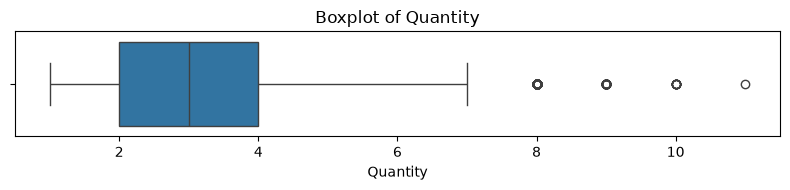

In [34]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Quantity"])
plt.title("Boxplot of Quantity")
plt.tight_layout()
plt.show()

#### 5. Discount_Percent

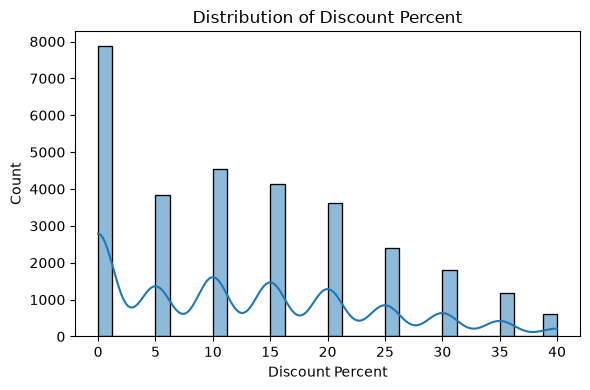

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(df["Discount_Percent"], kde=True)
plt.title("Distribution of Discount Percent")
plt.xlabel("Discount Percent")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [37]:
df["Discount_Percent"].describe()

count    30000.000000
mean        12.618667
std         11.085201
min          0.000000
25%          0.000000
50%         10.000000
75%         20.000000
max         40.000000
Name: Discount_Percent, dtype: float64

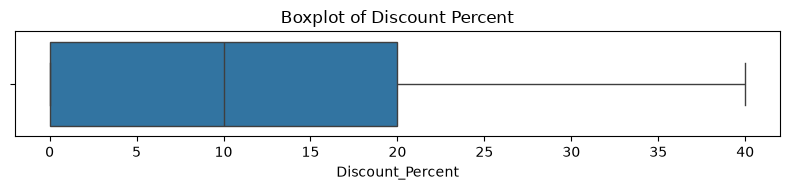

In [38]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Discount_Percent"])
plt.title("Boxplot of Discount Percent")
plt.tight_layout()
plt.show()

#### 6. Profit_Amount

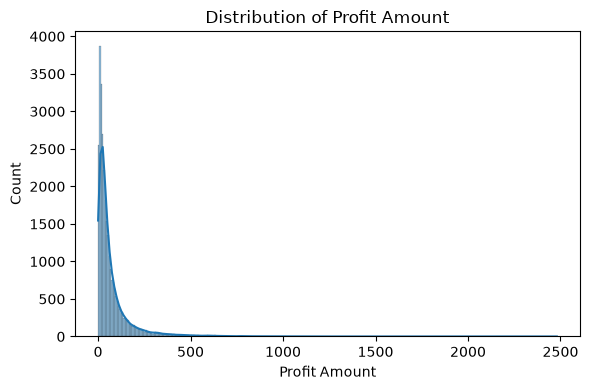

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df["Profit_Amount"], kde=True)
plt.title("Distribution of Profit Amount")
plt.xlabel("Profit Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [40]:
df["Profit_Amount"].describe()

count    30000.000000
mean        73.863876
std        113.480736
min          0.270000
25%         16.640000
50%         36.995000
75%         82.125000
max       2480.540000
Name: Profit_Amount, dtype: float64

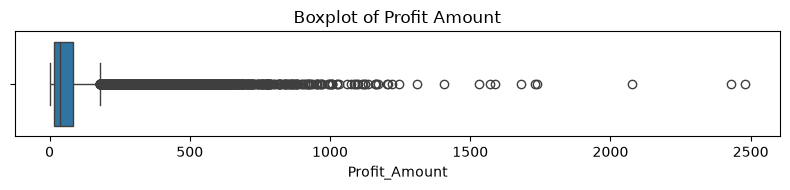

In [41]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Profit_Amount"])
plt.title("Boxplot of Profit Amount")
plt.tight_layout()
plt.show()

#### 7. Customer_Lifetime_Value

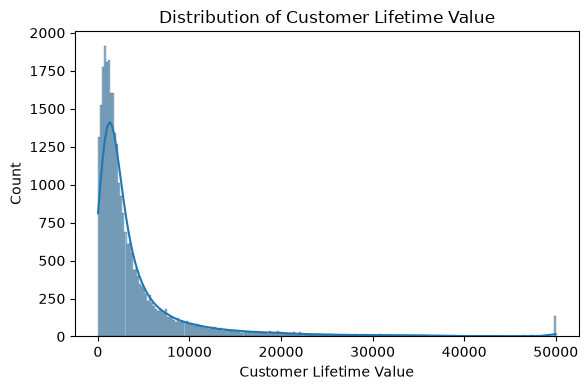

In [42]:
plt.figure(figsize=(6,4))
sns.histplot(df["Customer_Lifetime_Value"], kde=True)
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("Customer Lifetime Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [43]:
df["Customer_Lifetime_Value"].describe()

count    30000.000000
mean      4372.340178
std       6811.029394
min         20.000000
25%       1029.637500
50%       2073.365000
75%       4482.105000
max      50000.000000
Name: Customer_Lifetime_Value, dtype: float64

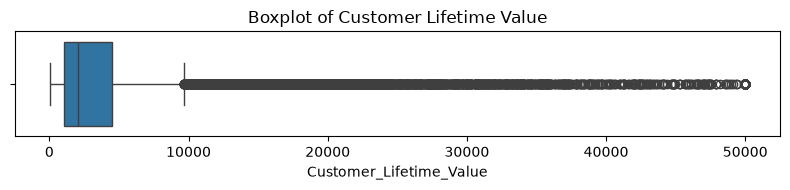

In [44]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Customer_Lifetime_Value"])
plt.title("Boxplot of Customer Lifetime Value")
plt.tight_layout()
plt.show()

In [50]:
list(df.select_dtypes(include=["object", "string"]).columns)

['Customer_ID',
 'Order_Date',
 'Day_Of_Week',
 'Customer_Gender',
 'Country',
 'City',
 'Customer_Segment',
 'Product_ID',
 'Product_Category',
 'Product_Subcategory',
 'Brand',
 'Coupon_Used',
 'Payment_Method',
 'Device_Type',
 'Traffic_Source',
 'Membership_Status',
 'Shipping_Method',
 'Warehouse_Region',
 'Order_Status',
 'Returned',
 'Season',
 'Holiday_Season',
 'High_Value_Order']

## 2.2 Univariate Analysis of Categorical Features

#### 1. Customer Segment

In [51]:
df["Customer_Segment"].value_counts()

Customer_Segment
Returning    11987
New           7794
Loyal         7214
Premium       3005
Name: count, dtype: int64

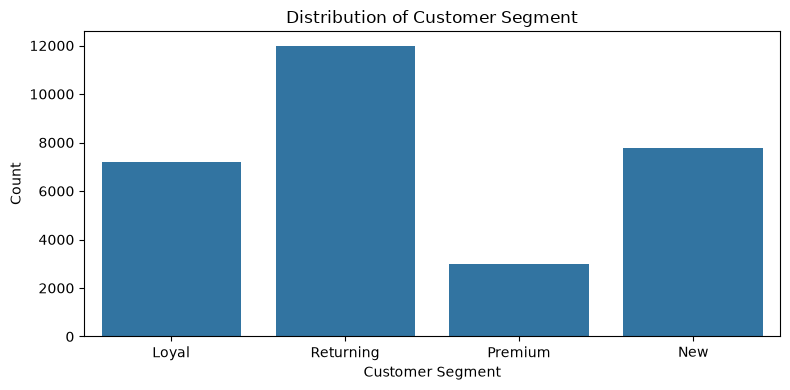

In [52]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Customer_Segment")
plt.title("Distribution of Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 2. Customer Gender

In [53]:
df["Customer_Gender"].value_counts()

Customer_Gender
Female    14863
Male      14552
Other       585
Name: count, dtype: int64

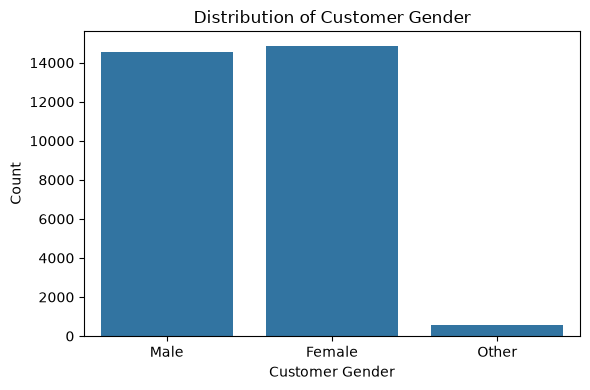

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Customer_Gender")
plt.title("Distribution of Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 3. Membership Status

In [55]:
df["Membership_Status"].value_counts()

Membership_Status
Standard    16049
Silver       7246
Gold         4916
Platinum     1789
Name: count, dtype: int64

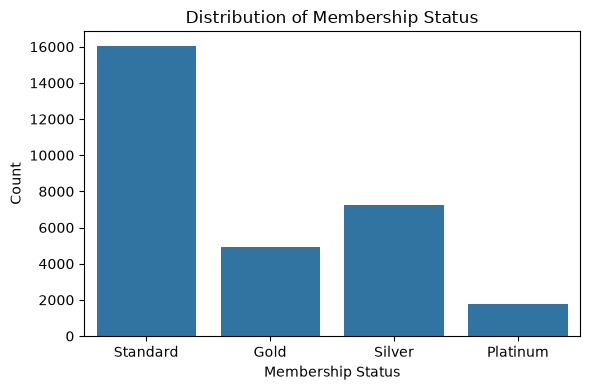

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Membership_Status")
plt.title("Distribution of Membership Status")
plt.xlabel("Membership Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 4. Product Category

In [57]:
df["Product_Category"].value_counts()

Product_Category
Fashion           6092
Groceries         5380
Electronics       4699
Home & Kitchen    4194
Beauty            2971
Sports            2439
Books             2163
Toys              2062
Name: count, dtype: int64

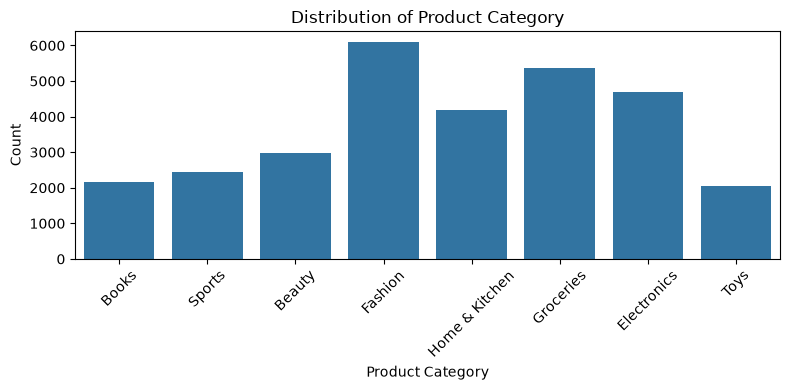

In [58]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Product_Category")
plt.title("Distribution of Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5. Product Subcategory

In [59]:
df["Product_Subcategory"].value_counts()

Product_Subcategory
Men Clothing      1591
Women Clothing    1515
Bags              1497
Shoes             1489
Beverages         1385
Snacks            1381
Dairy             1317
Fresh Produce     1297
Mobile            1216
Laptop            1171
Accessories       1167
Headphones        1145
Furniture         1063
Cookware          1062
Decor             1036
Appliances        1033
Haircare           769
Fragrance          755
Skincare           738
Makeup             709
Fitness            639
Equipment          605
Outdoor            599
Sportswear         596
Comics             558
Fiction            555
Educational        555
Education          540
Non-Fiction        510
Puzzles            507
Action Figures     503
Board Games        497
Name: count, dtype: int64

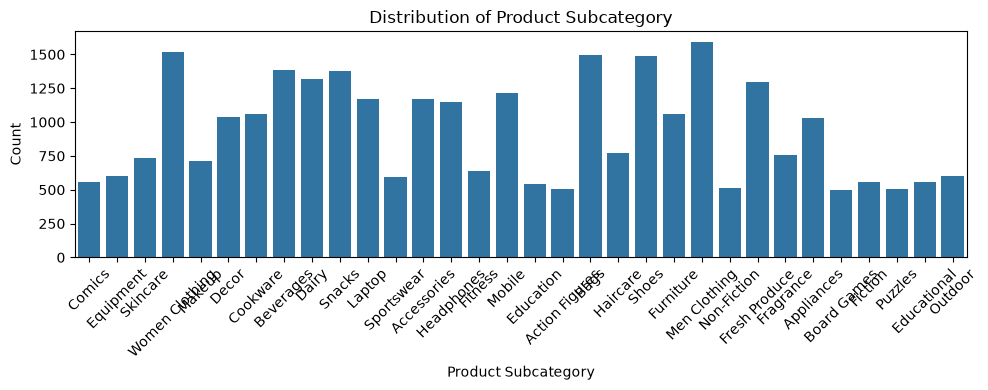

In [60]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Product_Subcategory")
plt.title("Distribution of Product Subcategory")
plt.xlabel("Product Subcategory")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 6. Brand

In [61]:
df["Brand"].value_counts()

Brand
Zenith       3099
QuickCart    3048
Trendify     3014
EcoLife      3009
PrimePlus    3004
Nova         2988
ValueMax     2987
UrbanCo      2986
FreshMart    2981
Apex         2884
Name: count, dtype: int64

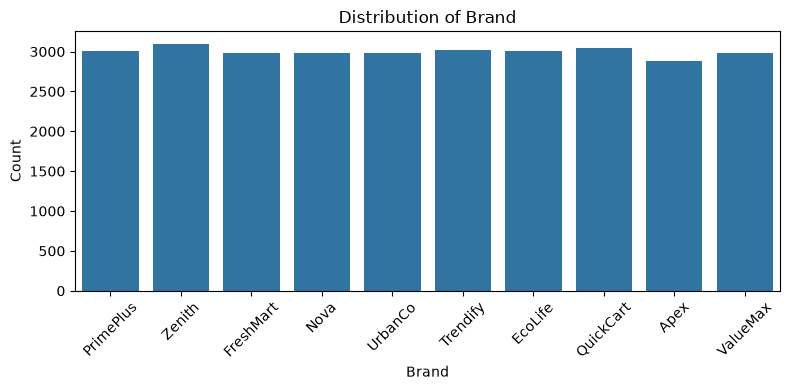

In [62]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Brand")
plt.title("Distribution of Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7. Payment Method

In [63]:
df["Payment_Method"].value_counts()

Payment_Method
Credit Card         5080
PayPal              5006
Bank Transfer       5002
Wallet              4977
Debit Card          4969
Cash on Delivery    4966
Name: count, dtype: int64

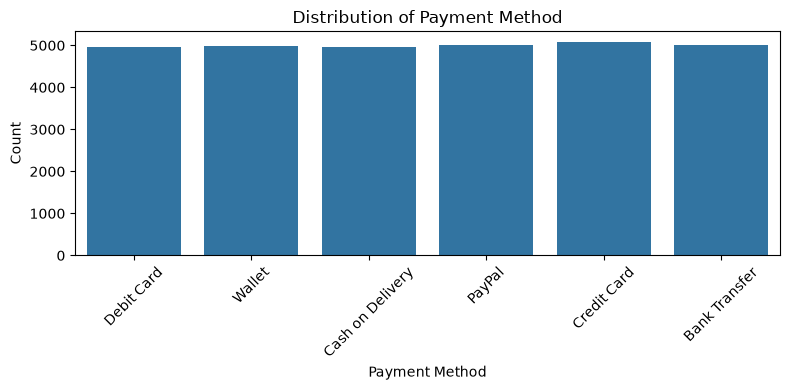

In [64]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Payment_Method")
plt.title("Distribution of Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8. Shipping Method

In [65]:
df["Shipping_Method"].value_counts()

Shipping_Method
Standard    16420
Express      7914
Pickup       2955
Same Day     2711
Name: count, dtype: int64

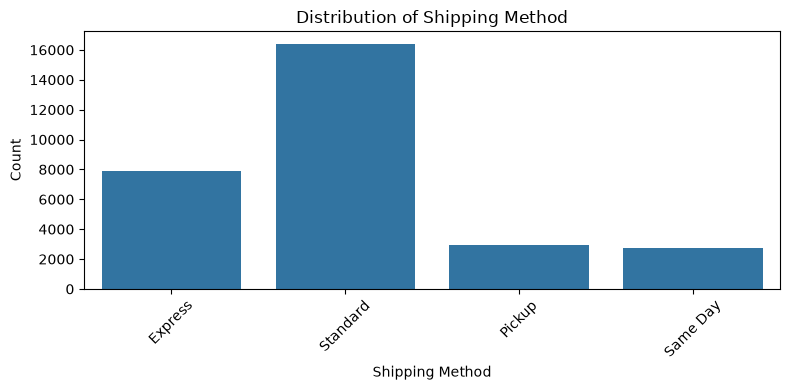

In [66]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Shipping_Method")
plt.title("Distribution of Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 9. Device Type

In [67]:
df["Device_Type"].value_counts()

Device_Type
Mobile     18538
Desktop     9085
Tablet      2377
Name: count, dtype: int64

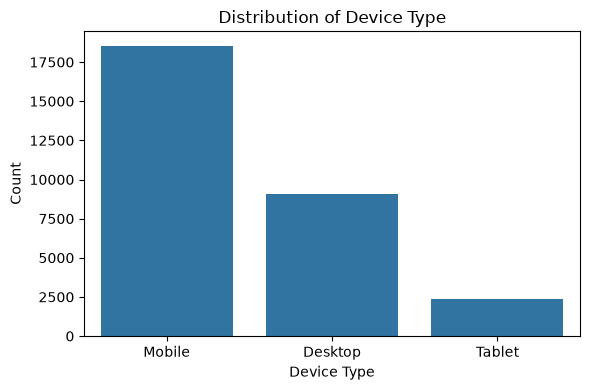

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Device_Type")
plt.title("Distribution of Device Type")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 10. Traffic Source

In [69]:
df["Traffic_Source"].value_counts()

Traffic_Source
Organic Search    5098
Direct            5073
Social Media      5059
Referral          5010
Email             4949
Paid Ads          4811
Name: count, dtype: int64

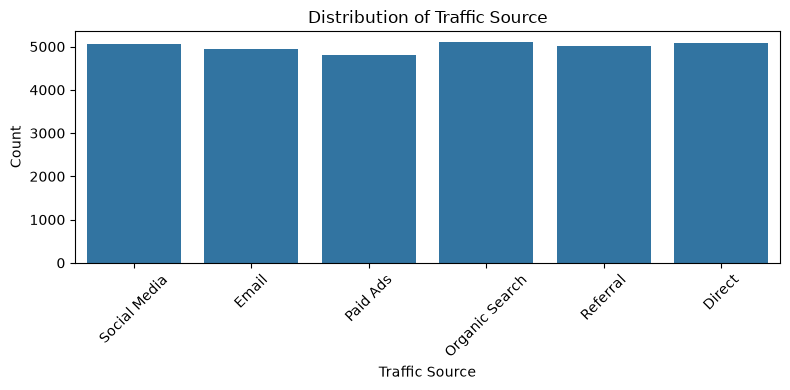

In [70]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Traffic_Source")
plt.title("Distribution of Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 11. Country

In [71]:
df["Country"].value_counts().head(10)

Country
Canada            3099
United Kingdom    3083
United States     3047
France            3023
Australia         3001
Saudi Arabia      2984
India             2972
UAE               2964
Germany           2957
Pakistan          2870
Name: count, dtype: int64

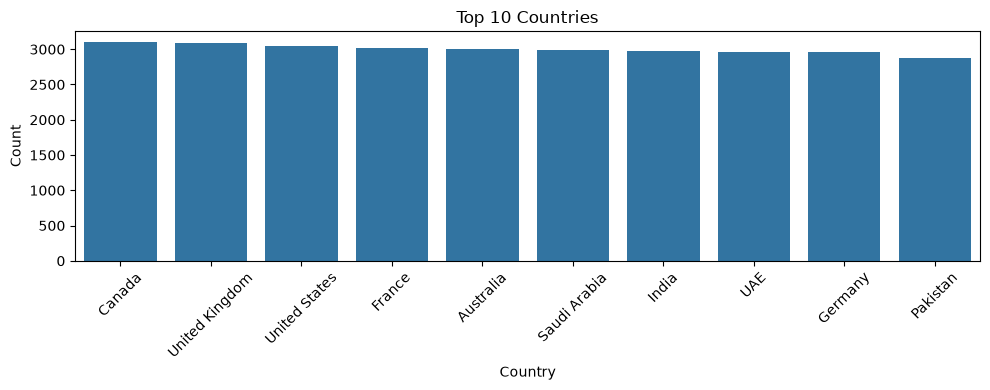

In [72]:
plt.figure(figsize=(10,4))
sns.countplot(
    data=df,
    x="Country",
    order=df["Country"].value_counts().head(10).index
)
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 12. Warehouse Region

In [73]:
df["Warehouse_Region"].value_counts()

Warehouse_Region
West       6060
South      6035
East       5990
Central    5981
North      5934
Name: count, dtype: int64

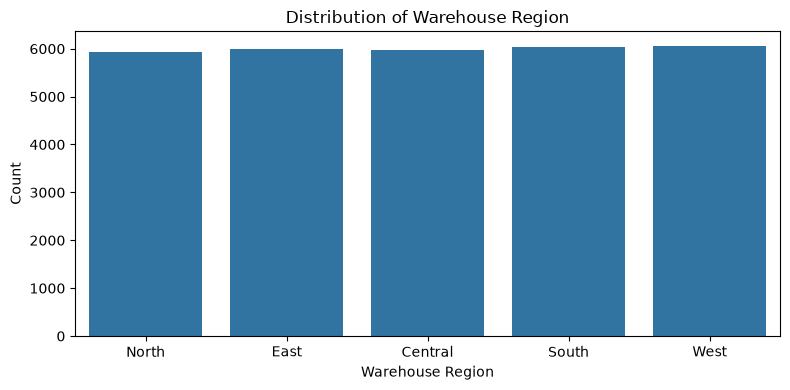

In [74]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Warehouse_Region")
plt.title("Distribution of Warehouse Region")
plt.xlabel("Warehouse Region")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 13. Coupon Used

In [77]:
df["Coupon_Used"].value_counts()

Coupon_Used
Yes    20429
No      9571
Name: count, dtype: int64

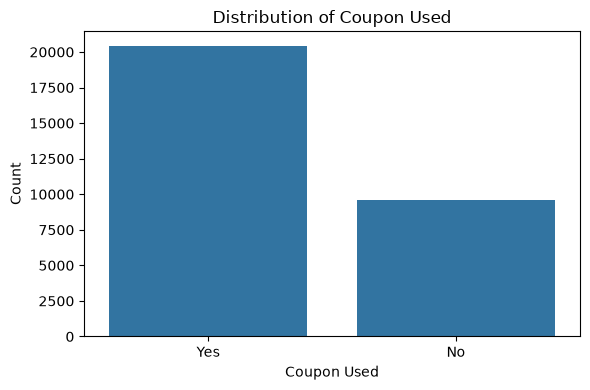

In [78]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Coupon_Used")
plt.title("Distribution of Coupon Used")
plt.xlabel("Coupon Used")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 14. Holiday Season

In [79]:
df["Holiday_Season"].value_counts()

Holiday_Season
No     25550
Yes     4450
Name: count, dtype: int64

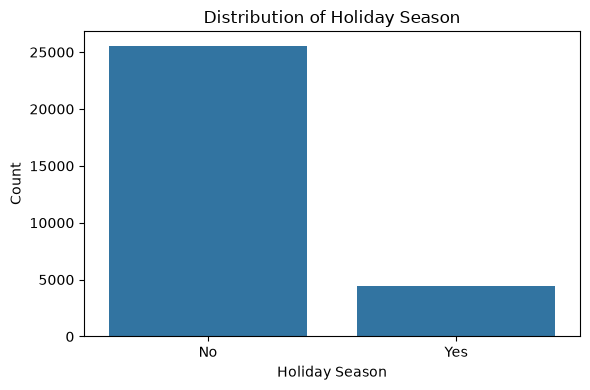

In [80]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Holiday_Season")
plt.title("Distribution of Holiday Season")
plt.xlabel("Holiday Season")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 15. Order Status

In [81]:
df["Order_Status"].value_counts()

Order_Status
Delivered     19497
Shipped        3469
Returned       3033
Processing     2230
Cancelled      1771
Name: count, dtype: int64

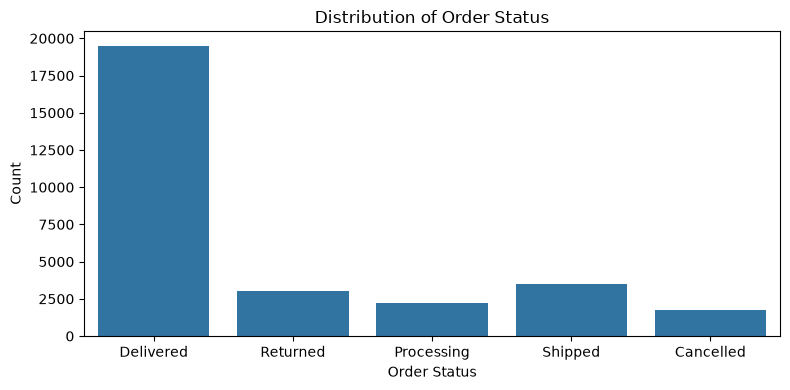

In [82]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Order_Status")
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 16 Returned

In [83]:
df["Returned"].value_counts()

Returned
No     26967
Yes     3033
Name: count, dtype: int64

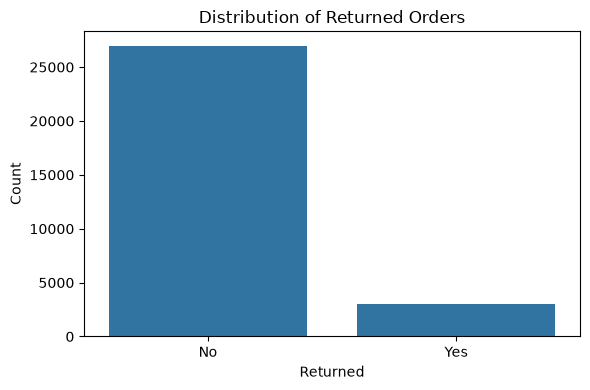

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Returned")
plt.title("Distribution of Returned Orders")
plt.xlabel("Returned")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.4 Bivariate Analysis

#### 1. Order Amount vs High Value Order

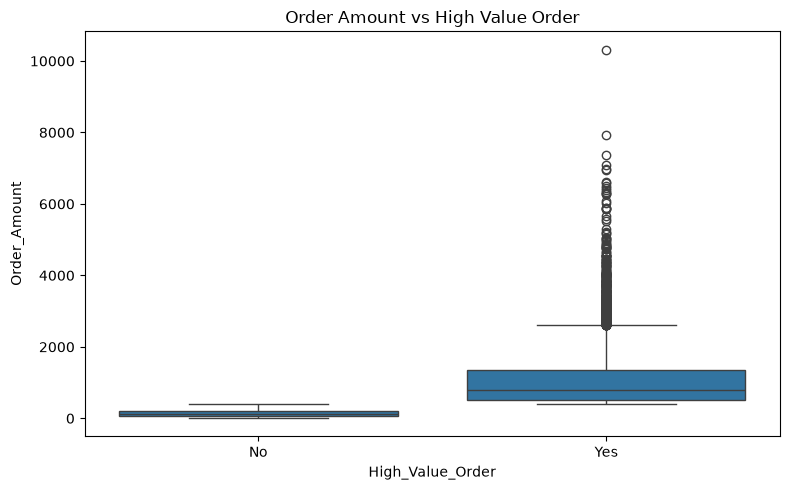

In [86]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="High_Value_Order", y="Order_Amount")
plt.title("Order Amount vs High Value Order")
plt.tight_layout()
plt.show()

#### 2. Customer Lifetime Value vs High Value Order

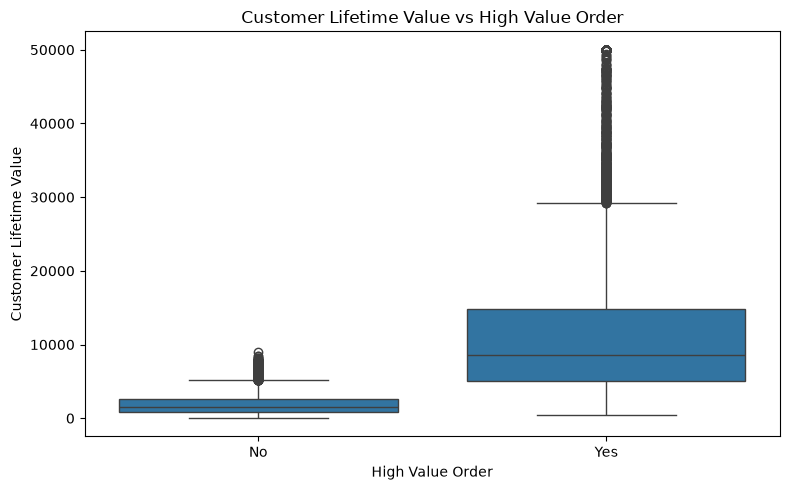

In [87]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="High_Value_Order", y="Customer_Lifetime_Value")
plt.title("Customer Lifetime Value vs High Value Order")
plt.xlabel("High Value Order")
plt.ylabel("Customer Lifetime Value")
plt.tight_layout()
plt.show()

#### 3. Profit Amount vs High Value Order

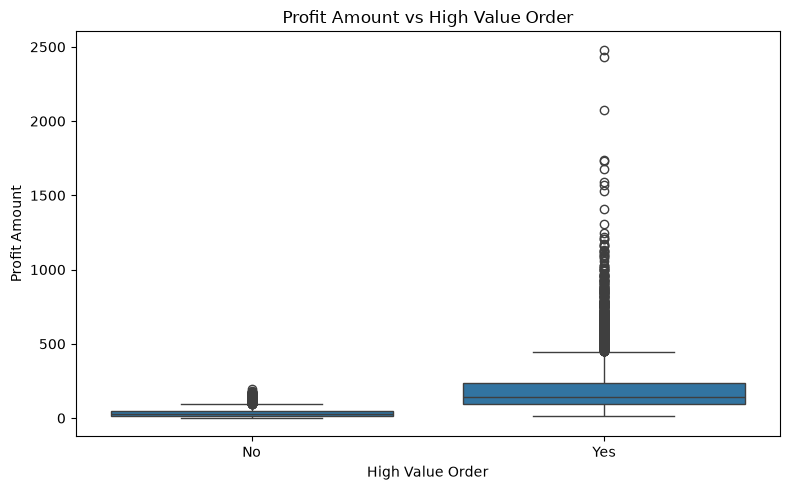

In [88]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="High_Value_Order", y="Profit_Amount")
plt.title("Profit Amount vs High Value Order")
plt.xlabel("High Value Order")
plt.ylabel("Profit Amount")
plt.tight_layout()
plt.show()

#### 4. Discount Percent vs High Value Order

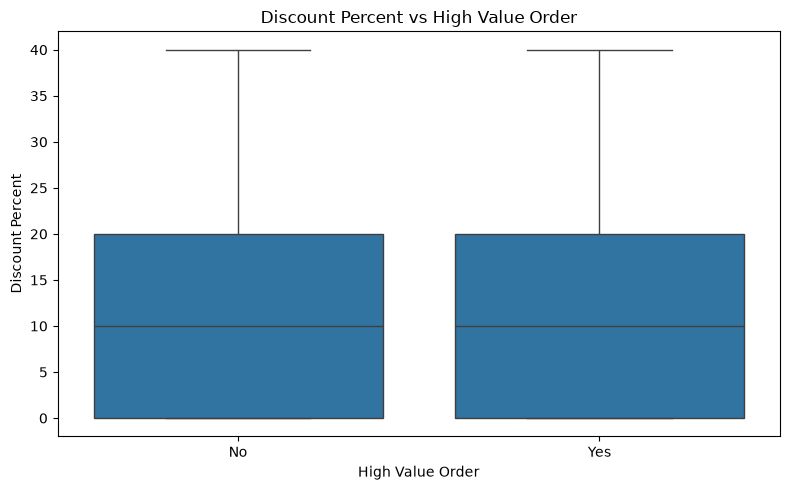

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="High_Value_Order", y="Discount_Percent")
plt.title("Discount Percent vs High Value Order")
plt.xlabel("High Value Order")
plt.ylabel("Discount Percent")
plt.tight_layout()
plt.show()

#### 5. Customer Segment vs High Value Order

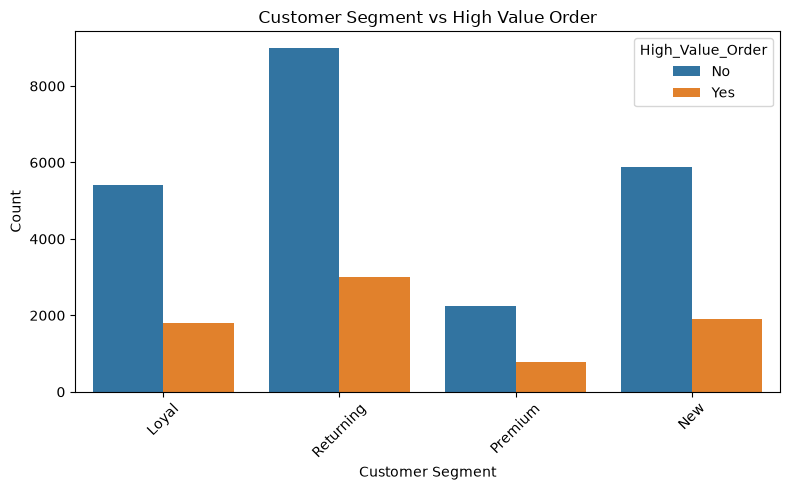

In [90]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Customer_Segment", hue="High_Value_Order")
plt.title("Customer Segment vs High Value Order")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 6. Membership Status vs High Value Order

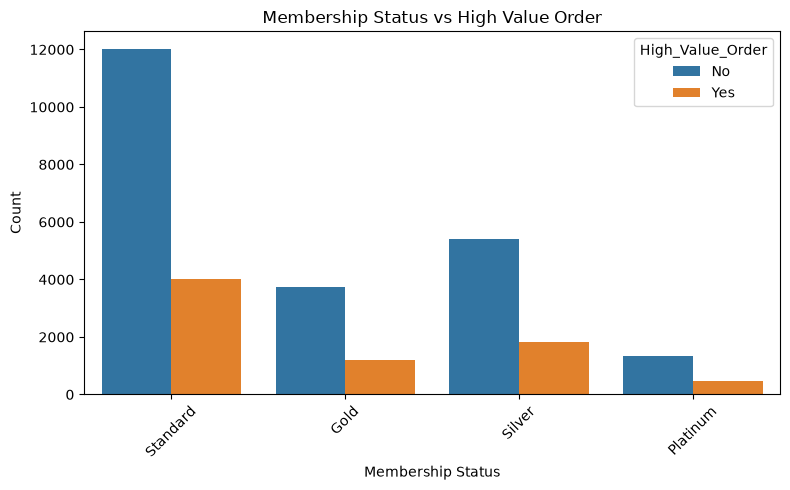

In [91]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Membership_Status", hue="High_Value_Order")
plt.title("Membership Status vs High Value Order")
plt.xlabel("Membership Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 7. Product Category vs High Value Order

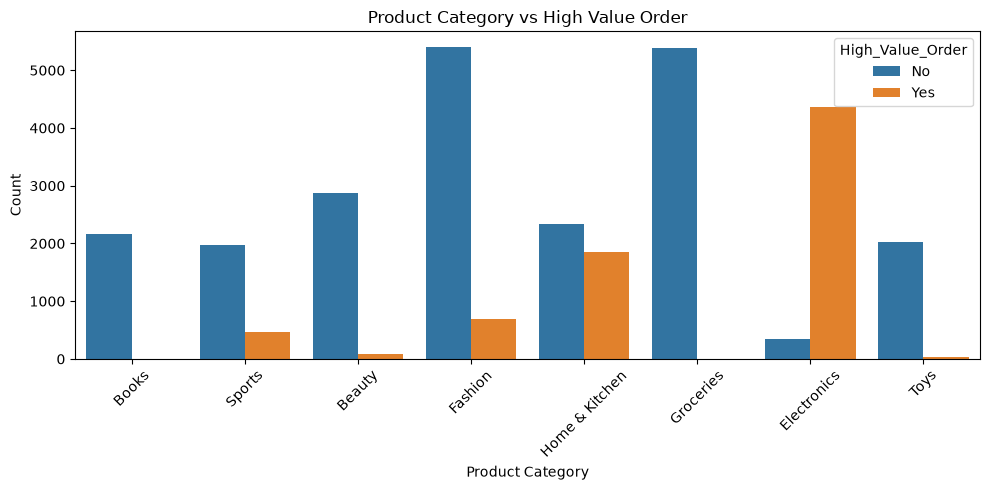

In [92]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Product_Category", hue="High_Value_Order")
plt.title("Product Category vs High Value Order")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8. Season vs High Value Order

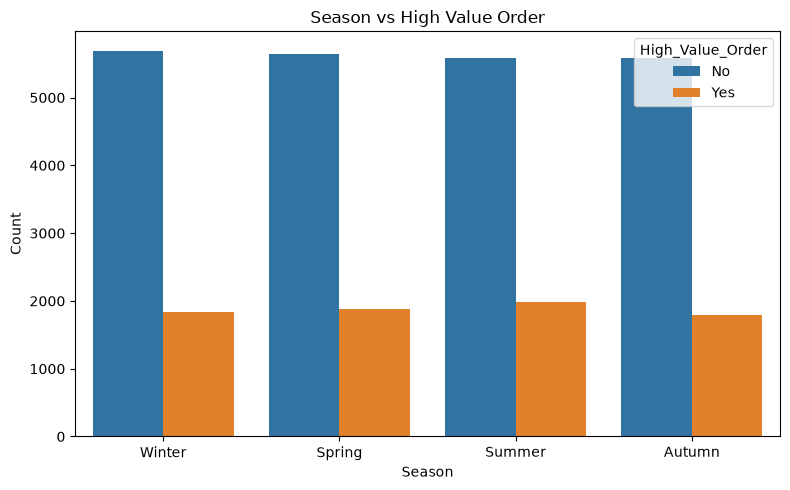

In [93]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season", hue="High_Value_Order")
plt.title("Season vs High Value Order")
plt.xlabel("Season")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.5 Correlation Analysis

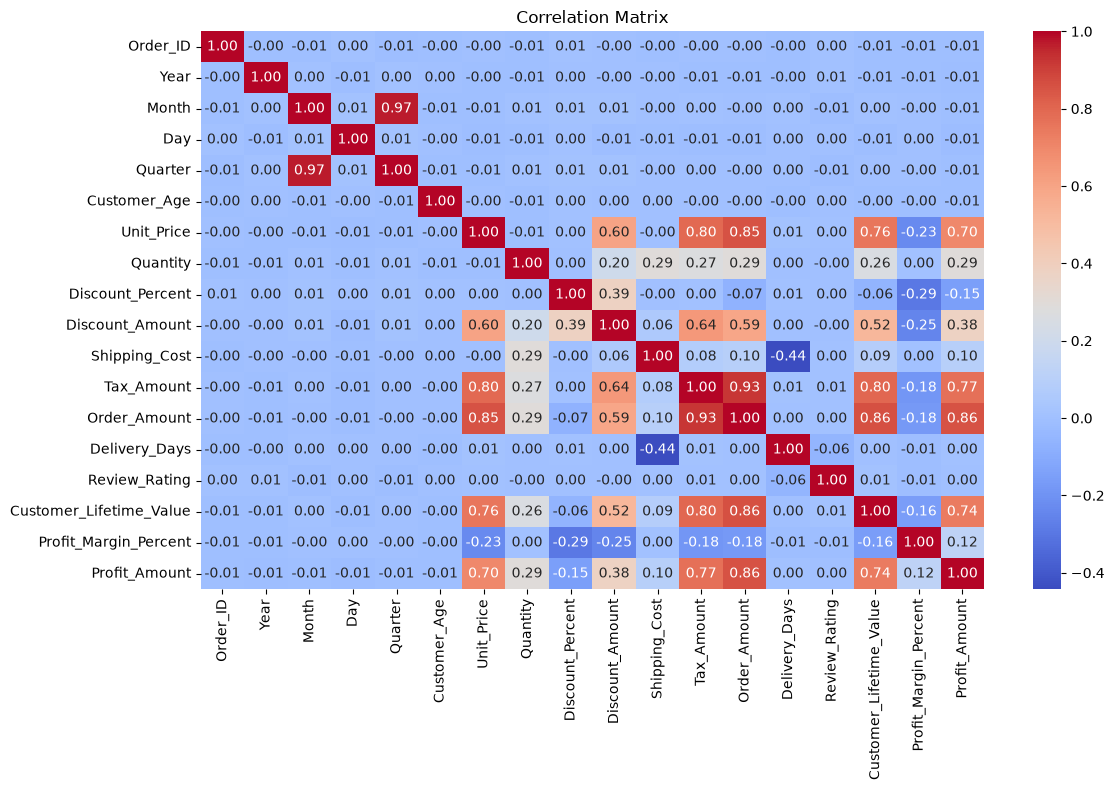

In [94]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [95]:
df["Order_Status"].value_counts()

Order_Status
Delivered     19497
Shipped        3469
Returned       3033
Processing     2230
Cancelled      1771
Name: count, dtype: int64

In [96]:
df["Returned"].value_counts()

Returned
No     26967
Yes     3033
Name: count, dtype: int64

In [97]:
df["Review_Rating"].describe()

count    30000.000000
mean         4.047990
std          0.686492
min          1.000000
25%          3.600000
50%          4.100000
75%          4.600000
max          5.000000
Name: Review_Rating, dtype: float64

In [98]:
# Convert Order_Date to datetime format
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Display the date range
print("Start Date:", df["Order_Date"].min())
print("End Date:", df["Order_Date"].max())

Start Date: 2023-01-01 00:00:00
End Date: 2026-12-31 00:00:00
